In [1]:
import numpy as np
import numba as nb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates

from tqdm import tqdm

# ----------------------------
# Settings
# ----------------------------
forward_csv_path = "../data/forward_prices.csv"

# ----------------------------
# Load forward curve on calendar-day grid
# ----------------------------
forward_curve = pd.read_csv(forward_csv_path)
forward_curve["date"] = pd.to_datetime(forward_curve["date"]).dt.normalize()

data = (
    forward_curve
    .loc[(forward_curve["date"] >= "2024-01-02") & (forward_curve["date"] <= "2025-12-31")]
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)
data["t"]   = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["F0t"] = data["forward_price"].astype(float)

Tn    = len(data)
t_arr = data["t"].to_numpy()
F_arr = data["F0t"].to_numpy()   # deterministic forward prices

# ============================================================
# MODEL PARAMETERS
# ============================================================
alpha_c          = 10000.0
refine_factor    = 4
alpha_f          = alpha_c / refine_factor   # 2 500

r_annual         = 0.1
terminal_penalty = -np.inf

# Step-varying discount on calendar-day grid (diff is 1 for all ordinary steps).
disc_arr = np.exp(-r_annual * np.diff(t_arr) / 365.0)   # shape (T,), disc_arr[t] for step t->t+1

# ============================================================
# Constraint helpers
# ============================================================

# ---------- vmax: constant ----------
VMAX_CONST = 10_125_000.0

# ---------- Rate caps ----------
INJECTMAX_BASE = 3_780.0 * 24.0
WDRMAX_BASE    = 7_500.0 * 24.0

# ---------- vmin: technical-feasibility floor from dated anchors ----------
VMIN_BASE = 0.0
_VMIN_CYCLE_START  = pd.Timestamp("2024-01-01")
_VMIN_CYCLE_LENGTH = 365 + 366

# Anchor dates are exact calendar dates — no snapping needed.
_RAW_ANCHOR_DATES = pd.to_datetime([
    "2024-02-01",
    "2024-05-01",
    "2024-07-01",
    "2024-09-01",
    "2024-11-01",
    "2025-02-01",
    "2025-05-01",
    "2025-07-01",
    "2025-09-01",
    "2025-11-01",
])
_VMIN_ANCHOR_DATES = pd.DatetimeIndex(_RAW_ANCHOR_DATES)
_VMIN_ANCHOR_VALUES = VMAX_CONST * np.array([
    0.45, 0.40, 0.60, 0.80, 0.90,
    0.45, 0.40, 0.60, 0.75, 0.90,
], dtype=np.float64)
_VMIN_ANCHOR_X = (_VMIN_ANCHOR_DATES - _VMIN_CYCLE_START).days.to_numpy()
# Include previous/current/next cycles so the floor respects both
# backward-looking withdrawal feasibility and forward-looking injection
# feasibility across the two-year repeating pattern.
_VMIN_ANCHOR_X_ALL = np.r_[
    _VMIN_ANCHOR_X - _VMIN_CYCLE_LENGTH,
    _VMIN_ANCHOR_X,
    _VMIN_ANCHOR_X + _VMIN_CYCLE_LENGTH,
]
_VMIN_ANCHOR_Y_ALL = np.r_[
    _VMIN_ANCHOR_VALUES,
    _VMIN_ANCHOR_VALUES,
    _VMIN_ANCHOR_VALUES,
]

def feasible_vmin_for_dates(dates_like) -> np.ndarray:
    dates = pd.DatetimeIndex(dates_like)
    date_x = (dates - _VMIN_CYCLE_START).days.to_numpy()
    feasible_floor = np.empty(len(dates), dtype=np.float64)
    inj_max = INJECTMAX_BASE
    wdr_max = WDRMAX_BASE
    for i, t in enumerate(date_x):
        future_mask = _VMIN_ANCHOR_X_ALL >= t
        past_mask   = _VMIN_ANCHOR_X_ALL <= t

        days_to_future = _VMIN_ANCHOR_X_ALL[future_mask] - t
        days_from_past = t - _VMIN_ANCHOR_X_ALL[past_mask]

        required_for_future = (
            _VMIN_ANCHOR_Y_ALL[future_mask] - inj_max * days_to_future
        ).max()
        required_from_past = (
            _VMIN_ANCHOR_Y_ALL[past_mask] - wdr_max * days_from_past
        ).max()

        feasible_floor[i] = np.clip(
            max(required_for_future, required_from_past),
            VMIN_BASE,
            VMAX_CONST,
        )
    return feasible_floor

def vmin_at_date(date: pd.Timestamp) -> float:
    return float(feasible_vmin_for_dates(pd.DatetimeIndex([date]))[0])

def inj_cap(fill_frac: float) -> float:
    return (0.75 if fill_frac >= 0.95 else 1.00) * INJECTMAX_BASE

def wdr_cap(fill_frac: float) -> float:
    if   fill_frac <= 0.05:  cap = 0.25
    elif fill_frac <= 0.125: cap = 0.50
    elif fill_frac <= 0.15:  cap = 0.75
    elif fill_frac <= 0.20:  cap = 0.85
    else:                    cap = 1.00
    return cap * WDRMAX_BASE

# ============================================================
# Per-date constraint arrays
# ============================================================
dates_pd = pd.DatetimeIndex(data["date"].to_numpy())

vmax_arr = np.full(len(dates_pd), VMAX_CONST, dtype=np.float64)
vmin_arr = feasible_vmin_for_dates(dates_pd)

# v0 and vT_target: fixed level, snapped to fine grid
v_target_raw = 9_153_925.0
v0        = round(v_target_raw / alpha_f) * alpha_f
vT_target = round(v_target_raw / alpha_f) * alpha_f

print(f"v0        = {v0:>12,.0f}  (snapped from {v_target_raw:,.0f})")
print(f"vT_target = {vT_target:>12,.0f}  (snapped from {v_target_raw:,.0f})")
print(f"vmax range: {vmax_arr.min():,.0f} - {vmax_arr.max():,.0f}")
print(f"vmin range: {vmin_arr.min():,.0f} - {vmin_arr.max():,.0f}")


# ============================================================
# Volume grid
# ============================================================
VMIN_GLOBAL = 0.0
VMAX_GLOBAL = float(np.max(vmax_arr))

Nc = int(round((VMAX_GLOBAL - VMIN_GLOBAL) / alpha_c)) + 1
Nf = (Nc - 1) * refine_factor + 1

v_coarse        = VMIN_GLOBAL + alpha_c * np.arange(Nc, dtype=np.float64)
v_fine          = VMIN_GLOBAL + alpha_f * np.arange(Nf, dtype=np.float64)
coarse_fine_idx = (refine_factor * np.arange(Nc)).astype(np.int32)
assert coarse_fine_idx[-1] == Nf - 1, "Grid alignment check failed"

def fine_index_of(v: float) -> int:
    return int(round((v - VMIN_GLOBAL) / alpha_f))

n0_f  = fine_index_of(v0)
nT_f  = fine_index_of(vT_target)

print(f"\nGrid: Nc={Nc}, Nf={Nf}, n0_f={n0_f}, nT_f={nT_f}")

# ============================================================
# Terminal value: hard target at nT_f.
# ============================================================
def terminal_value(v_arr: np.ndarray) -> np.ndarray:
    tv = np.full_like(v_arr, terminal_penalty, dtype=np.float64)
    tv[nT_f] = 0.0
    return tv

# ============================================================
# Feasible action sets -- one per timestep
# ============================================================
def build_feasible_actions_at_t(t_idx: int):
    vm_t    = vmax_arr[t_idx]
    vn_t    = vmin_arr[t_idx]
    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    vm_next = vmax_arr[t_next]
    vn_next = vmin_arr[t_next]

    days = float(t_arr[t_next] - t_arr[t_idx]) if t_next != t_idx else 1.0
    days = max(days, 1.0)

    # First pass: determine K_max
    K_max_t = 0
    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        K_max_t = max(K_max_t, max(0, k_hi - k_lo + 1))

    K_max_t = max(K_max_t, 1)

    next_idx = np.full((Nf, K_max_t), -1, dtype=np.int32)
    dv_mat   = np.zeros((Nf, K_max_t), dtype=np.float64)
    K_len    = np.zeros(Nf, dtype=np.int32)

    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        if k_hi < k_lo:
            continue
        idxs = n_f + np.arange(k_lo, k_hi + 1, dtype=np.int32)
        idxs = idxs[(idxs >= 0) & (idxs < Nf)]
        k    = idxs.size
        K_len[n_f] = k
        if k:
            next_idx[n_f, :k] = idxs
            dv_mat[n_f,   :k] = v_fine[idxs] - v

    return next_idx, dv_mat, K_len


print("Pre-computing feasible action sets ...")
all_next_idx = []
all_dv_mat   = []
all_K_len    = []
all_dest_ok  = []

for t_idx in range(Tn):
    ni, dv, kl = build_feasible_actions_at_t(t_idx)
    all_next_idx.append(ni)
    all_dv_mat.append(dv)
    all_K_len.append(kl)

    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    all_dest_ok.append(
        (v_fine >= vmin_arr[t_next] - 1e-6) &
        (v_fine <= vmax_arr[t_next] + 1e-6)
    )

T = Tn - 1
all_can_reach = [np.zeros(Nf, dtype=np.bool_) for _ in range(T + 1)]
all_can_reach[T][nT_f] = True
for t_idx in range(T - 1, -1, -1):
    can_reach_next = all_can_reach[t_idx + 1]
    can_reach_now  = all_can_reach[t_idx]
    ni_t = all_next_idx[t_idx]
    kl_t = all_K_len[t_idx]
    for n_f in range(Nf):
        klen = kl_t[n_f]
        if klen == 0:
            continue
        can_reach_now[n_f] = np.any(can_reach_next[ni_t[n_f, :klen]])

print("Done.")

# ============================================================
# Numba kernel: one deterministic Bellman step
# ============================================================

@nb.njit(fastmath=True)
def bellman_intrinsic(Y_current, pi_row, F_t, Y_disc,
                      next_idx_mat, dv_mat, K_len, terminal_penalty):
    """Bellman update using known forward price F_t.
    Continuation value is deterministic: disc_arr[t] * Y_next[nxt].
    """
    Nf = next_idx_mat.shape[0]
    for n_f in range(Nf):
        klen = K_len[n_f]
        if klen == 0:
            Y_current[n_f] = terminal_penalty
            pi_row[n_f]    = -1
            continue
        best_val  = terminal_penalty
        best_next = -1
        for k in range(klen):
            nxt  = next_idx_mat[n_f, k]
            dv   = dv_mat[n_f, k]
            cand = (-F_t * dv) + Y_disc[nxt]
            if cand > best_val:
                best_val  = cand
                best_next = nxt
        Y_current[n_f] = best_val
        pi_row[n_f]    = best_next

# ============================================================
# Backward induction (deterministic / intrinsic)
# ============================================================
pi        = np.full((T, Nf), -1, dtype=np.int32)
tv        = terminal_value(v_fine)
Y_next    = tv.copy()
Y_current = np.empty(Nf, dtype=np.float64)

for t in tqdm(range(T - 1, -1, -1), desc="Backward induction"):
    Y_disc = disc_arr[t] * Y_next
    bellman_intrinsic(
        Y_current, pi[t], float(F_arr[t]), Y_disc,
        all_next_idx[t], all_dv_mat[t], all_K_len[t],
        terminal_penalty,
    )
    Y_next, Y_current = Y_current, Y_next

V0 = float(Y_next[n0_f])
print(f"\nV0 = {V0:,.2f}")

# ============================================================
# Forward rollout: reconstruct optimal volume path
# ============================================================
n      = n0_f
v_path = np.empty(T + 1, dtype=np.float64)
v_path[0] = v_fine[n0_f]

for t in range(T):
    n_next = int(pi[t, n])
    if n_next < 0:
        raise RuntimeError(f"No feasible policy at t={t}, state index n={n}.")
    v_path[t + 1] = v_fine[n_next]
    n = n_next

v0        =    9,155,000  (snapped from 9,153,925)
vT_target =    9,155,000  (snapped from 9,153,925)
vmax range: 10,125,000 - 10,125,000
vmin range: 0 - 9,112,500

Grid: Nc=1013, Nf=4049, n0_f=3662, nT_f=3662
Pre-computing feasible action sets ...
Done.


Backward induction: 100%|██████████| 729/729 [00:01<00:00, 468.68it/s]


V0 = 78,998,642.53


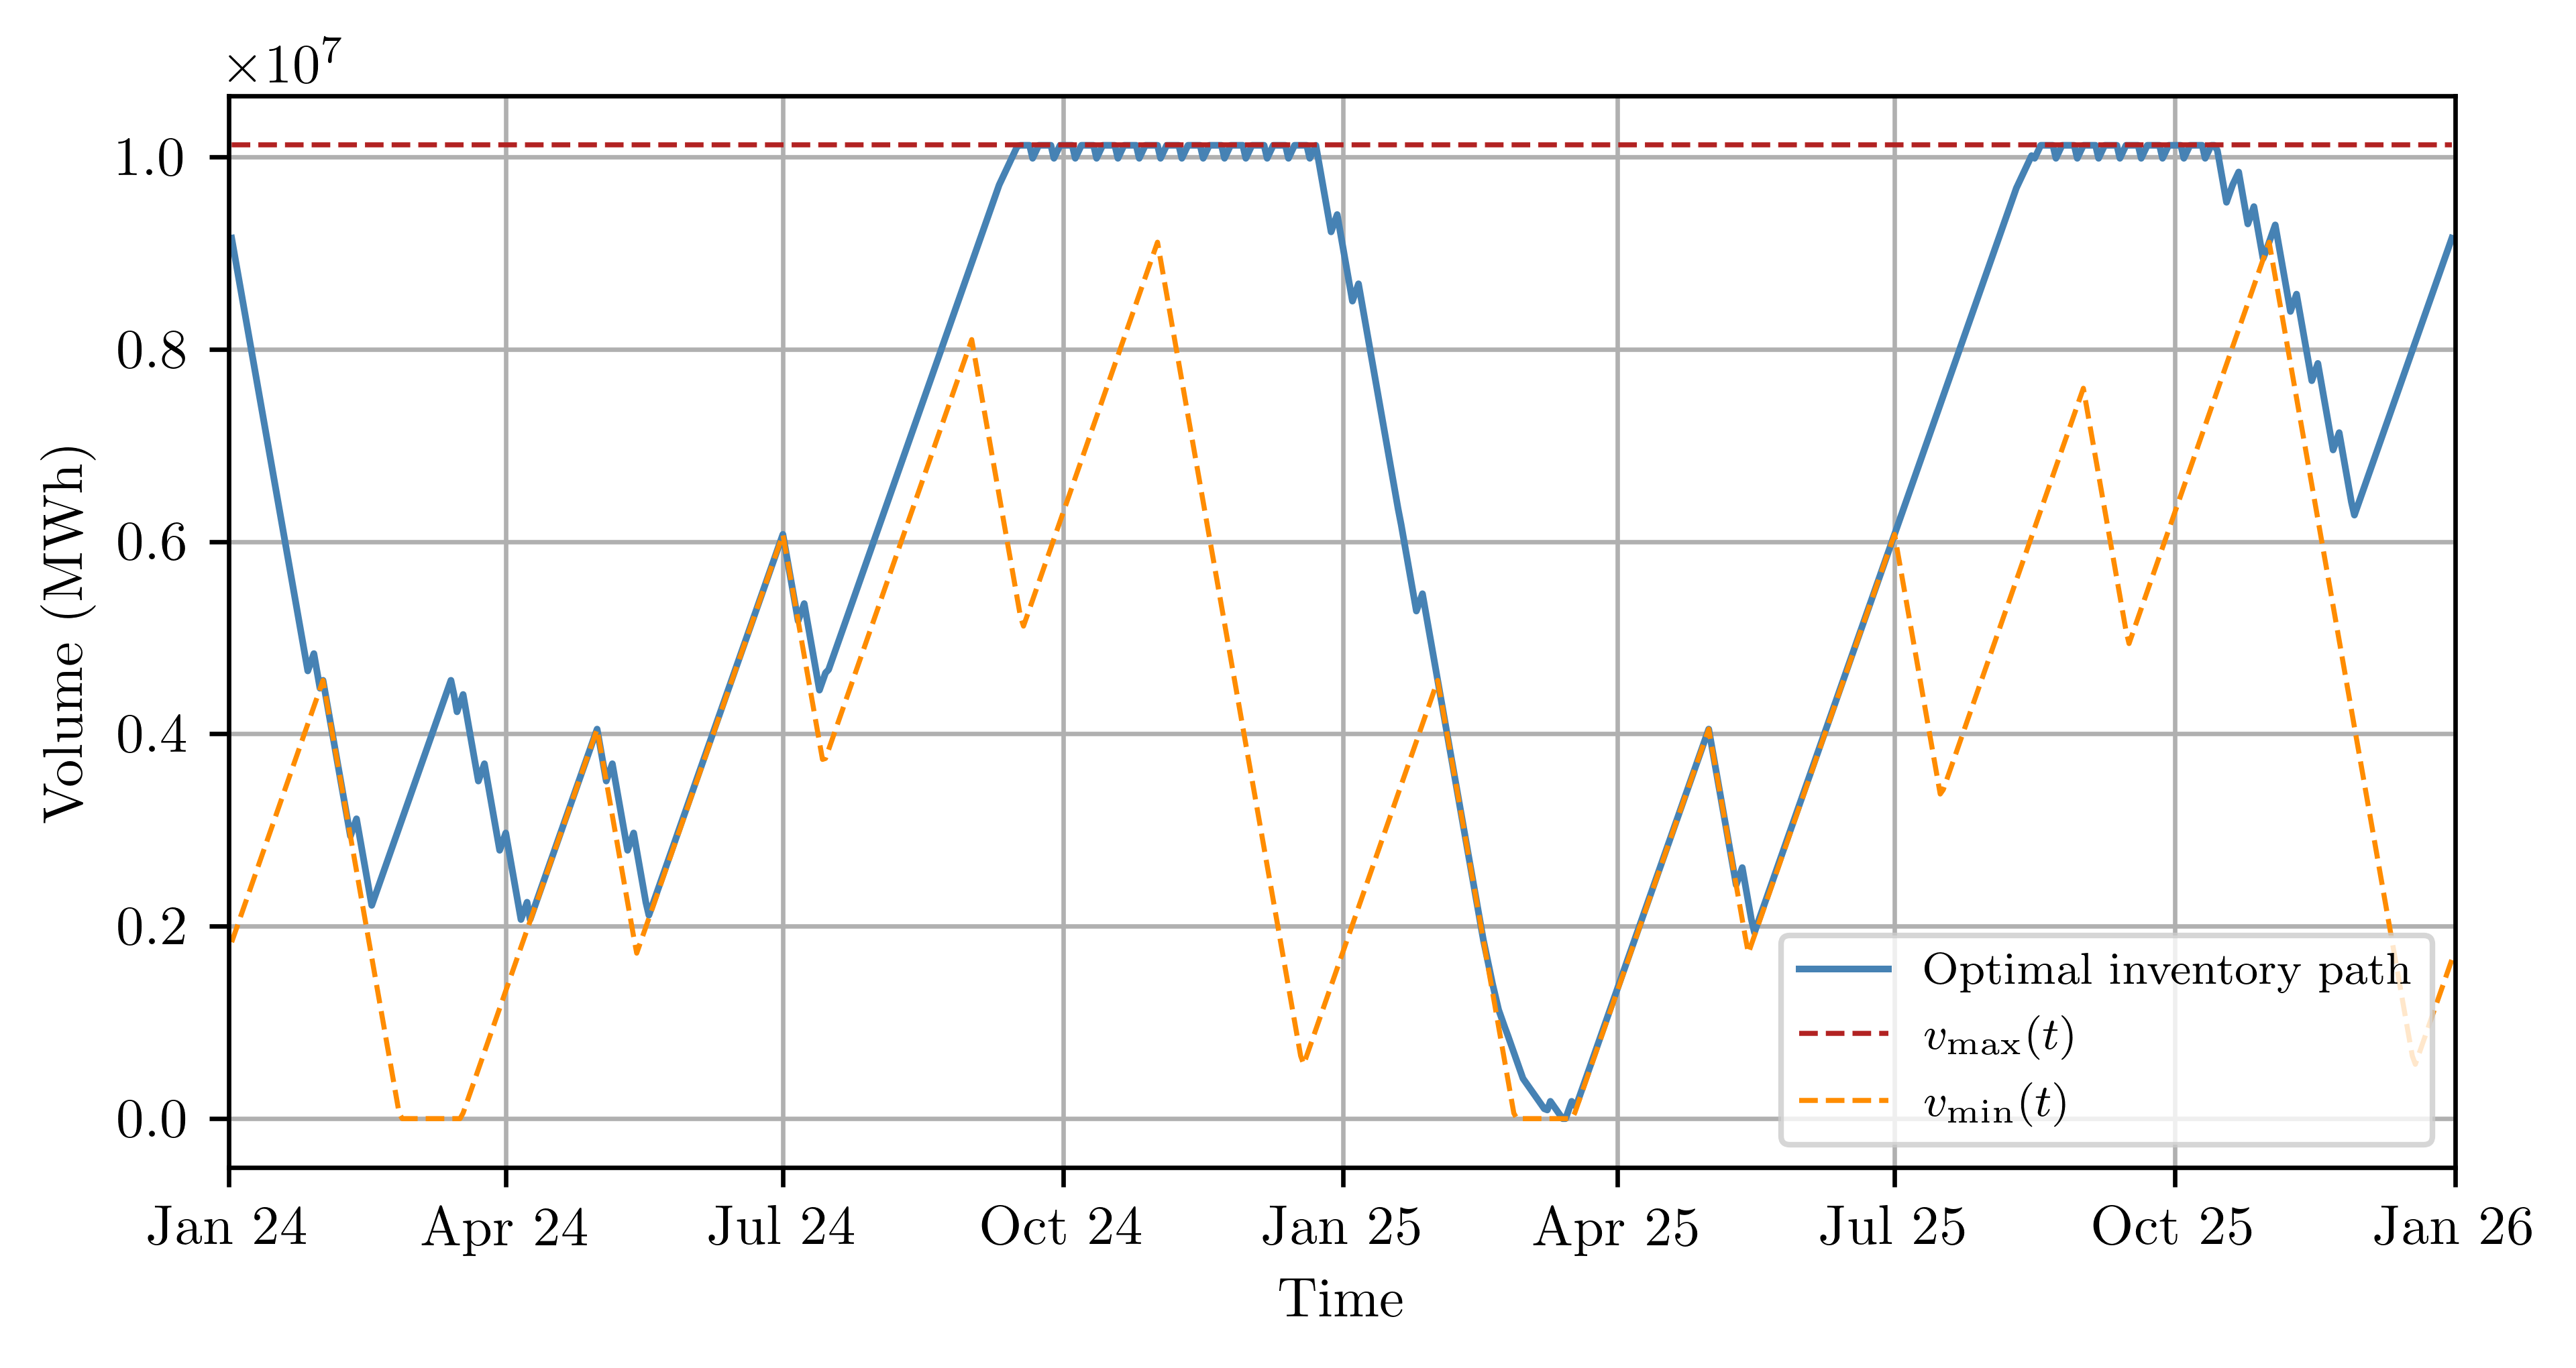

In [3]:
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif":  ["Computer Modern Roman"],
})

x_start = pd.Timestamp("2024-01-01")
x_end   = pd.Timestamp("2026-01-01")

dates_plot = pd.DatetimeIndex(data["date"].to_numpy())

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

# Optimal inventory path (single deterministic path)
ax.plot(dates_plot, v_path, color="steelblue", lw=1.2,
        label="Optimal inventory path")

# Constraint curves — calendar-day arrays from cell 0
ax.step(dates_plot, vmax_arr, where="post", color="firebrick",
        lw=0.9, ls="--", label=r"$v_{\max}(t)$")
ax.plot(dates_plot, vmin_arr, color="darkorange",
        lw=0.9, ls="--", label=r"$v_{\min}(t)$")

ax.set_xlabel("Time")
ax.set_ylabel("Volume (MWh)")
ax.grid(True)

tick_dates = pd.date_range(start=x_start, end=pd.Timestamp("2026-01-01"), freq="3MS")
ax.set_xlim(x_start, x_end)
ax.set_xticks([mdates.date2num(d) for d in tick_dates])
ax.set_xticklabels([d.strftime("%b %y") for d in tick_dates])

ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.savefig("../../fig/Plots/intrinsic_valuation_optimal_path_GSD.png")
plt.show()


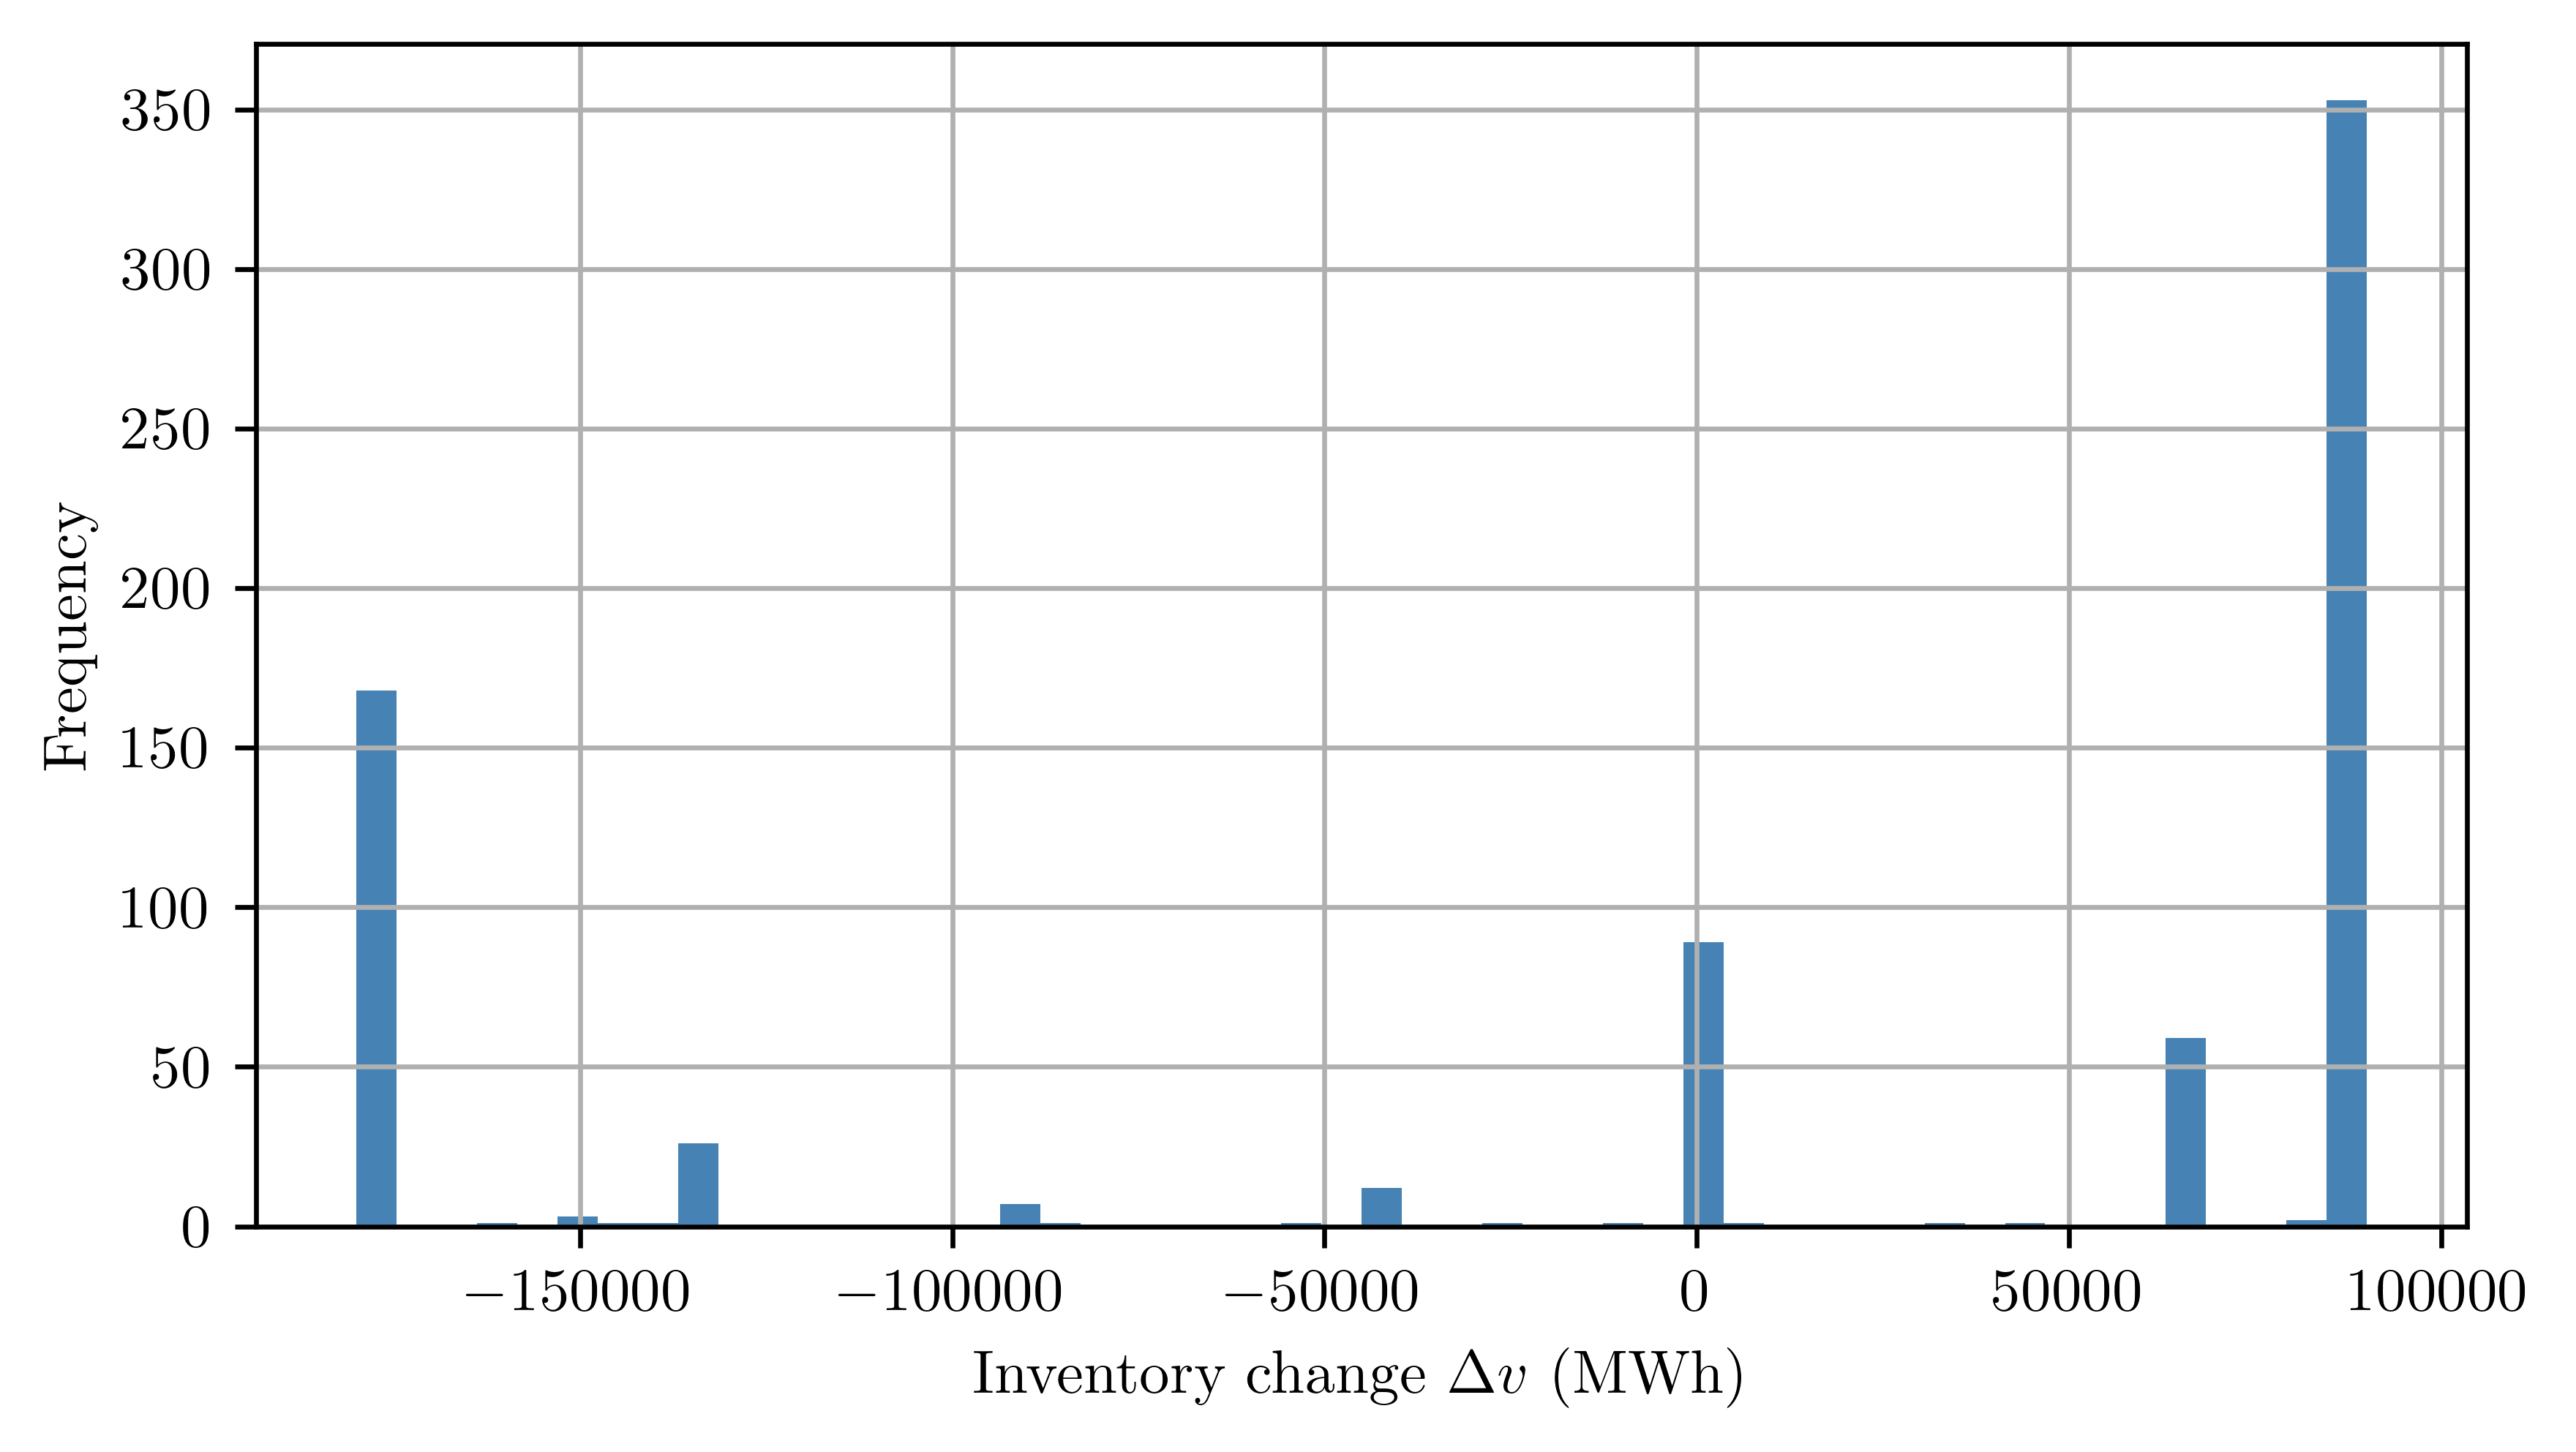

In [ ]:
# Load realised_paths_OLS_GSD.npz
delta_v_path = np.diff(v_path, axis=0)

# Print a inventory change frequency histogram
plt.figure(figsize=(6.5, 3.5), dpi=600)
plt.hist(delta_v_path.flatten(), bins=50, alpha=1, color = "steelblue")
plt.xlabel("Inventory change $\\Delta v$ (MWh)")
plt.ylabel("Frequency")
plt.grid()
plt.savefig("../../fig/Plots/intrinsic_valuation_inventory_change_distribution_GSD.png")
plt.show()